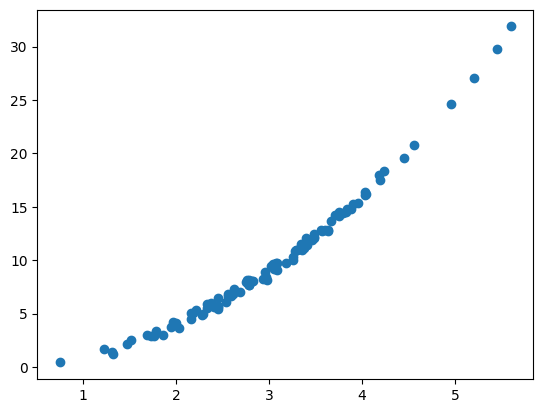

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 3
sig = 1
prc = 100

X = np.random.normal(x0, sig, prc)
Y = X**2 + np.random.normal(0, 0.3, prc) # добавляем немного шума, чтобы было больше похоже на реальность

tb = np.column_stack((X, X**2)) #матрица 100 на 2 

plt.scatter(X, Y)
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

x_tr, xt, y_tr, yt = train_test_split(tb, Y, test_size=0.2, random_state=9)

Xm = np.asarray(x_tr)# Приводим к массивам numpy 
Ym = np.asarray(y_tr)
lam = 0.8

X_ex = np.column_stack([Xm, np.ones(Xm.shape[0])]) #X.shape[0] -- выдает кол-во кортеж (кол-во сттрок, кол-во столбцов)
I = np.eye(X_ex.shape[1])
#model = Ridge(alpha=0.8)
#model.fit(x_tr, y_tr)
W = np.linalg.inv(X_ex.T @ X_ex + lam * I) @ X_ex.T @ Ym

w1 = W[0] #model.coef_[0]
w2 = W[1] #model.coef_[1]
b = W[2] #model.intercept_

0.057323517513795594


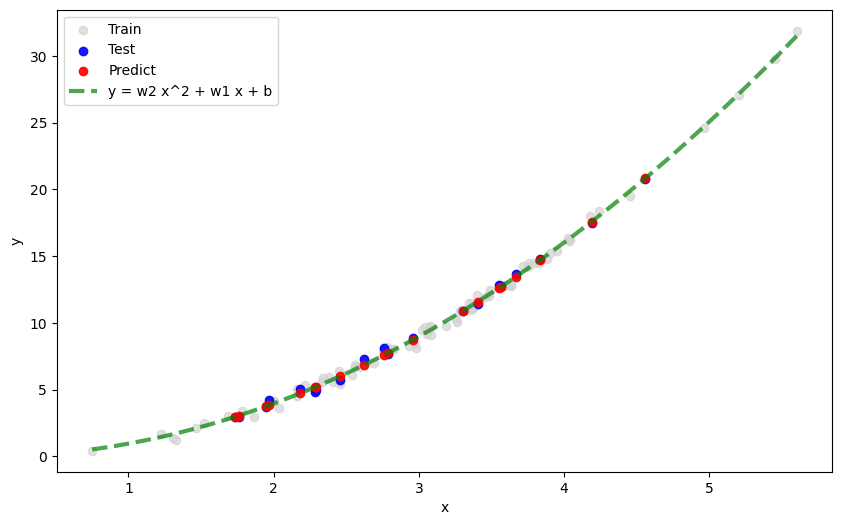

In [8]:
from sklearn.metrics import mean_squared_error
y_pr = w1 * xt[:, 0] + w2 * xt[:, 1] + b
err = mean_squared_error(yt, y_pr)
print(err)

ind_s = xt[:, 0].argsort()
xt_s = xt[ind_s, 0]
y_pr_s = y_pr[ind_s]

x_fine = np.linspace(X.min(), X.max(), 500)
y_fine = w2 * (x_fine**2) + w1 * x_fine + b

plt.figure(figsize=(10, 6))
plt.scatter(x_tr[:, 0], y_tr, color= 'lightgrey', label= 'Train', alpha=0.7)
plt.scatter(xt[:, 0], yt, color='blue', label='Test', alpha=0.9)
plt.scatter(xt[:, 0], y_pr, color='red', label='Predict', alpha=0.9)
#plt.plot(xt_s, y_pr_s, color='red', linewidth=3, label='Predict')
plt.plot(x_fine, y_fine, color='green', linewidth=3, label='y = w2 x^2 + w1 x + b', linestyle='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

ker = C(1.0) * RBF(length_scale=1) + WhiteKernel(noise_level=0.3)
gpm = GaussianProcessRegressor(kernel=ker, n_restarts_optimizer=5)
x_in = x_tr[:, 0].reshape(-1, 1)
gpm.fit(x_in, y_tr)


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP.If `None` is passed,the kernel `ConstantKernel() * RBF()` is used as default.Note thatthe kernel hyperparameters are optimized during fittingunless the bounds are marked as `""fixed""`or the argument `optimizer` is set to `None`.",1**2 * RBF(le...ise_level=0.3)
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",5
,kernel__k1,1**2 * RBF(length_scale=1)
,kernel__k2,WhiteKernel(noise_level=0.3)
,kernel__k1__k1,1**2
,kernel__k1__k2,RBF(length_scale=1)
,kernel__k1__k1__constant_value,1.0
,kernel__k1__k1__constant_value_bounds,"(1e-05, ...)"
,kernel__k1__k2__length_scale,1
,kernel__k1__k2__length_scale_bounds,"(1e-05, ...)"
,kernel__k2__noise_level,0.3


In [ ]:
xt_in = xt[:, 0].reshape(-1, 1)
y_mean, y_std = gpm.predict(xt_in, return_std=True)
err_g = mean_squared_error(yt, y_mean)


0.10996285451295038


0.10996285451295038


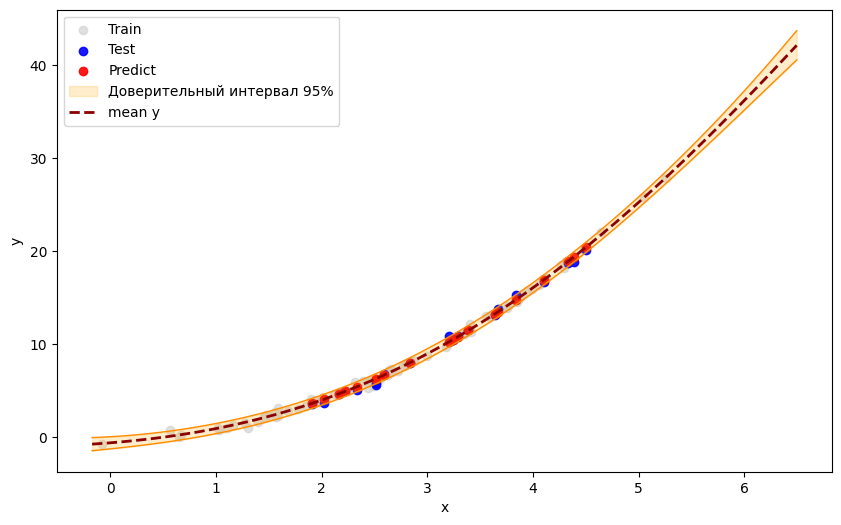

In [75]:
xp = np.linspace(X.min() - 1, X.max() + 1, 500).reshape(-1, 1)
yp_mu, yp_std = gpm.predict(xp, return_std=True)

print(err_g)

plt.figure(figsize=(10, 6))
plt.scatter(x_tr[:, 0], y_tr, color= 'lightgrey', label= 'Train', alpha=0.7)
plt.scatter(xt[:, 0], yt, color='blue', label='Test', alpha=0.9)
plt.scatter(xt[:, 0], y_mean, color='red', label='Predict', alpha=0.9)
plt.fill_between(xp.flatten(), yp_mu - 1.96 * yp_std, yp_mu + 1.96 * yp_std, alpha=0.2, color='orange', label='Доверительный интервал 95%')
plt.plot(xp, yp_mu, color='darkred', lw=2, label='mean y',  linestyle='--')
plt.plot(xp, yp_mu - 1.96 * yp_std, color='darkorange', lw=1)
plt.plot(xp, yp_mu + 1.96 * yp_std, color='darkorange', lw=1)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()
